# Caffeine Intake and Focus Level Analysis

## Project Overview

This project explores the relationship between caffeine intake, focus level, and sleep quality using Python and data analysis techniques.

The main goal is to investigate whether caffeine intake is associated with higher focus levels and how it relates to sleep quality.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib

### Dataset
The dataset contains 500 records and 13 variables related to caffeine intake, focus level, sleep quality, age, beverage type, and time of caffeine intake.

## 1. Loading the Dataset

The dataset was loaded from Google Drive using Pandas.

In [1]:
import pandas as pd

file_path = "/content/drive/MyDrive/Coffee Productivity Analysis/caffeine_intake_tracker.csv"

data = pd.read_csv(file_path)

print(data.shape)

(500, 13)


## 2. Exploring the Dataset

Before analyzing the relationships between caffeine, focus, and sleep quality, the dataset was explored to understand its structure, variables, and data types.

In [2]:
data.head()

,caffeine_mg,age,focus_level,sleep_quality,sleep_impacted,beverage_coffee,beverage_energy_drink,beverage_tea,time_of_day_afternoon,time_of_day_evening,time_of_day_morning,gender_female,gender_male
0,0.454545,1.000000,0.715384,0.749790,1,True,False,False,False,True,False,True,False
1,0.286364,0.833333,0.846471,0.730060,0,True,False,False,False,False,True,True,False
2,0.531818,0.476190,0.665639,0.276600,1,False,True,False,False,False,True,False,True
3,0.068182,0.642857,0.751364,0.654003,0,False,False,True,False,False,True,True,False
4,0.409091,0.047619,0.808104,0.709735,1,True,False,False,False,True,False,False,True


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   caffeine_mg            500 non-null    float64
 1   age                    500 non-null    float64
 2   focus_level            500 non-null    float64
 3   sleep_quality          500 non-null    float64
 4   sleep_impacted         500 non-null    int64  
 5   beverage_coffee        500 non-null    bool   
 6   beverage_energy_drink  500 non-null    bool   
 7   beverage_tea           500 non-null    bool   
 8   time_of_day_afternoon  500 non-null    bool   
 9   time_of_day_evening    500 non-null    bool   
 10  time_of_day_morning    500 non-null    bool   
 11  gender_female          500 non-null    bool   
 12  gender_male            500 non-null    bool   
dtypes: bool(8), float64(4), int64(1)
memory usage: 23.6 KB


## 3. Data Quality Check

The dataset was checked for missing values and its overall dimensions were confirmed before starting the analysis.

In [4]:
print("Dataset shape:", data.shape)

print("\nMissing values:")
print(data.isnull().sum())

Dataset shape: (500, 13)

Missing values:
caffeine_mg              0
age                      0
focus_level              0
sleep_quality            0
sleep_impacted           0
beverage_coffee          0
beverage_energy_drink    0
beverage_tea             0
time_of_day_afternoon    0
time_of_day_evening      0
time_of_day_morning      0
gender_female            0
gender_male              0
dtype: int64


## 4. Caffeine Intake and Focus Level

The first analysis examines the relationship between caffeine intake and focus level.

In [5]:
correlation_caffeine_focus = data["caffeine_mg"].corr(data["focus_level"])

print(f"Caffeine-Focus correlation: {correlation_caffeine_focus:.2f}")

Caffeine-Focus correlation: 0.55


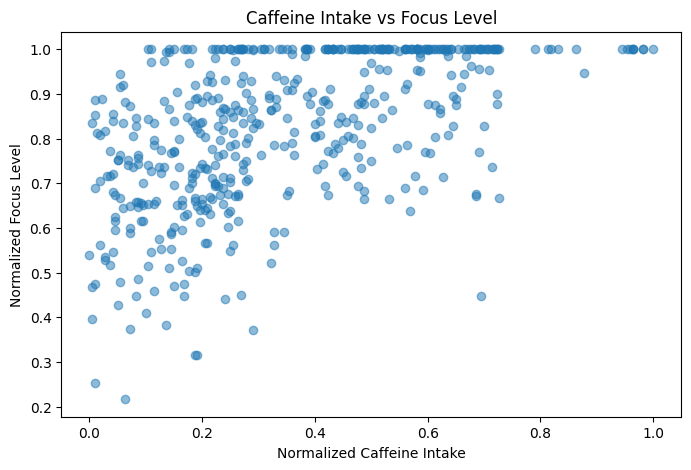

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    data["caffeine_mg"],
    data["focus_level"],
    alpha=0.5
)

plt.title("Caffeine Intake vs Focus Level")
plt.xlabel("Normalized Caffeine Intake")
plt.ylabel("Normalized Focus Level")

plt.show()

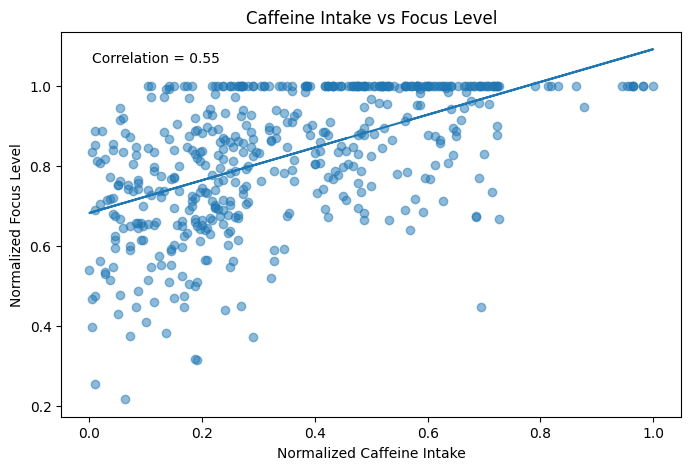

In [7]:
import numpy as np

x = data["caffeine_mg"]
y = data["focus_level"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.5)
plt.plot(x, m*x + b)

plt.title("Caffeine Intake vs Focus Level")
plt.xlabel("Normalized Caffeine Intake")
plt.ylabel("Normalized Focus Level")

plt.text(
    0.05, 0.95,
    f"Correlation = {x.corr(y):.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.show()

### Finding

The analysis shows a moderate positive correlation between caffeine intake and focus level (r = 0.55). Higher caffeine intake is associated with higher focus levels in this dataset. However, this correlation does not establish a causal relationship.

## 5. Caffeine Intake and Sleep Quality

The second analysis examines the relationship between caffeine intake and sleep quality.

In [8]:
correlation_caffeine_sleep = data["caffeine_mg"].corr(data["sleep_quality"])

print(f"Caffeine-Sleep correlation: {correlation_caffeine_sleep:.2f}")

Caffeine-Sleep correlation: -0.37


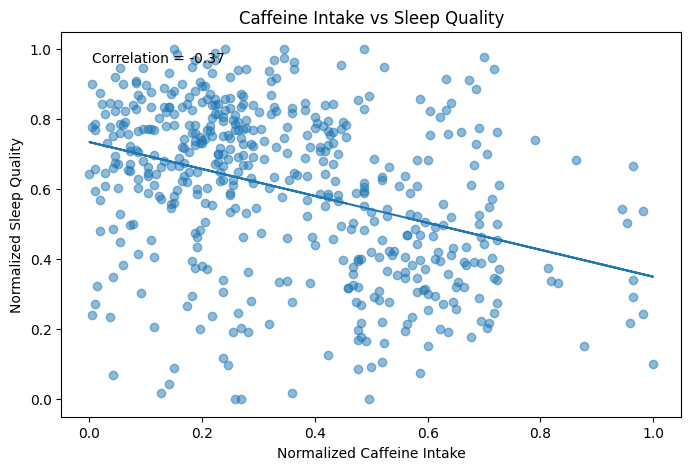

In [9]:
x = data["caffeine_mg"]
y = data["sleep_quality"]

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.5)
plt.plot(x, m*x + b)

plt.title("Caffeine Intake vs Sleep Quality")
plt.xlabel("Normalized Caffeine Intake")
plt.ylabel("Normalized Sleep Quality")

plt.text(
    0.05, 0.95,
    f"Correlation = {x.corr(y):.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.show()

### Finding

The analysis shows a moderate negative correlation between caffeine intake and sleep quality (r = -0.37). Higher caffeine intake is associated with lower sleep quality in this dataset. However, this correlation does not establish causation.

## 6. Focus Level by Caffeine Intake Group

To further explore the relationship between caffeine intake and focus, the dataset was divided into three caffeine intake groups: Low, Medium, and High.

In [10]:
data["caffeine_group"] = pd.qcut(
    data["caffeine_mg"],
    q=3,
    labels=["Low", "Medium", "High"]
)

In [11]:
focus_by_caffeine = data.groupby(
    "caffeine_group",
    observed=True
)["focus_level"].mean()

print(focus_by_caffeine)

caffeine_group
Low       0.704672
Medium    0.841475
High      0.931209
Name: focus_level, dtype: float64


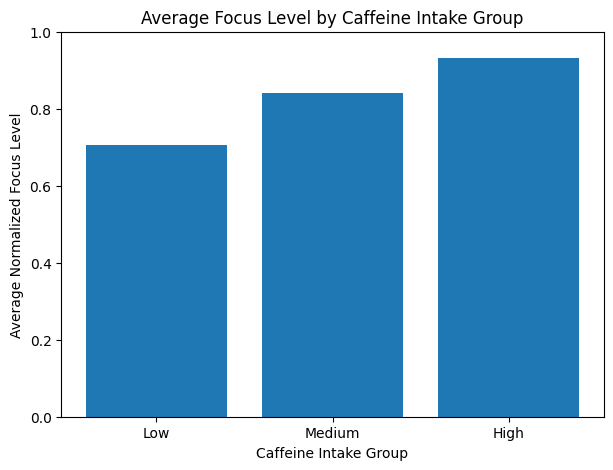

In [12]:
plt.figure(figsize=(7, 5))

plt.bar(
    focus_by_caffeine.index,
    focus_by_caffeine.values
)

plt.title("Average Focus Level by Caffeine Intake Group")
plt.xlabel("Caffeine Intake Group")
plt.ylabel("Average Normalized Focus Level")

plt.ylim(0, 1)

plt.show()

### Finding

The average focus level increased across the caffeine intake groups. The Low, Medium, and High groups had average focus levels of 0.705, 0.841, and 0.931 respectively. This shows a clear positive pattern between caffeine intake group and focus level in this dataset.

## 7. Conclusion

This analysis explored the relationship between caffeine intake, focus level, and sleep quality.

The results showed a moderate positive correlation between caffeine intake and focus level (r = 0.55). The average focus level also increased across the Low, Medium, and High caffeine groups.

At the same time, caffeine intake showed a moderate negative correlation with sleep quality (r = -0.37).

Overall, the dataset suggests that higher caffeine intake is associated with higher focus levels but lower sleep quality. These findings show associations within the dataset and do not establish that caffeine directly causes changes in focus or sleep quality.

## 8. Limitations

- The analysis is based on correlations and does not establish causation.
- The dataset contains normalized values, so the caffeine and focus values represent scaled measurements rather than their original units.
- Other factors may influence focus and sleep quality that were not examined in this analysis.

## Exploratory Analysis Notes

In [13]:
# The dataset is already extracted and saved in Google Drive.
# No need to extract archive.zip again.

In [14]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'coffee_data', 'sample_data']


In [15]:
data.shape

(500, 14)

In [16]:
data["focus_level"].describe()

,focus_level
count,500.000000
mean,0.825575
std,0.167635
min,0.216512
25%,0.711317
50%,0.850635
75%,1.000000
max,1.000000


In [17]:
data["caffeine_mg"].describe()

,caffeine_mg
count,500.000000
mean,0.349464
std,0.223971
min,0.000000
25%,0.177273
50%,0.290909
75%,0.518182
max,1.000000


In [18]:
data["caffeine_mg"].corr(data["focus_level"])

np.float64(0.5471399789686529)

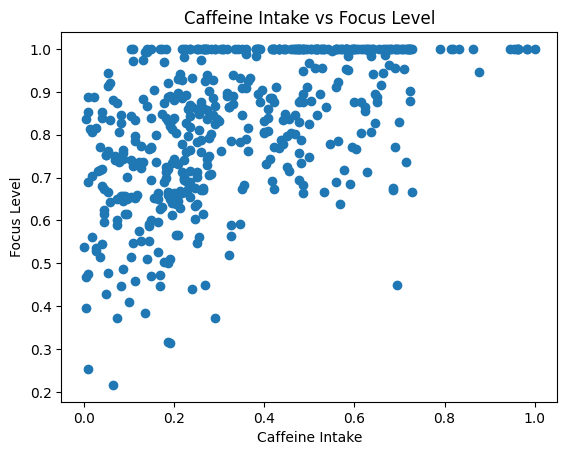

In [19]:
import matplotlib.pyplot as plt

plt.scatter(data["caffeine_mg"], data["focus_level"])
plt.xlabel("Caffeine Intake")
plt.ylabel("Focus Level")
plt.title("Caffeine Intake vs Focus Level")
plt.show()

In [20]:
print("Coffee:", data["beverage_coffee"].sum())
print("Energy Drink:", data["beverage_energy_drink"].sum())
print("Tea:", data["beverage_tea"].sum())

Coffee: 265
Energy Drink: 47
Tea: 188


In [21]:
coffee_focus = data.groupby(
    ["beverage_coffee", "beverage_energy_drink", "beverage_tea"]
)["focus_level"].mean()

coffee_focus

beverage_coffee  beverage_energy_drink  beverage_tea
False            False                  True            0.717470
                 True                   False           0.950308
True             False                  False           0.880145
Name: focus_level, dtype: float64

In [22]:
data.groupby(
    ["beverage_coffee", "beverage_energy_drink", "beverage_tea"]
)["caffeine_mg"].mean()

beverage_coffee  beverage_energy_drink  beverage_tea
False            False                  True            0.135662
                 True                   False           0.638588
True             False                  False           0.449863
Name: caffeine_mg, dtype: float64

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   caffeine_mg            500 non-null    float64 
 1   age                    500 non-null    float64 
 2   focus_level            500 non-null    float64 
 3   sleep_quality          500 non-null    float64 
 4   sleep_impacted         500 non-null    int64   
 5   beverage_coffee        500 non-null    bool    
 6   beverage_energy_drink  500 non-null    bool    
 7   beverage_tea           500 non-null    bool    
 8   time_of_day_afternoon  500 non-null    bool    
 9   time_of_day_evening    500 non-null    bool    
 10  time_of_day_morning    500 non-null    bool    
 11  gender_female          500 non-null    bool    
 12  gender_male            500 non-null    bool    
 13  caffeine_group         500 non-null    category
dtypes: bool(8), category(1), float64(4), int64

In [24]:
print("Age values:")
print(data["age"].unique())

print("\nCaffeine values:")
print(data["caffeine_mg"].unique()[:20])

Age values:
[1.         0.83333333 0.47619048 0.64285714 0.04761905 0.30952381
 0.16666667 0.97619048 0.71428571 0.5952381  0.14285714 0.52380952
 0.85714286 0.5        0.45238095 0.28571429 0.54761905 0.26190476
 0.02380952 0.11904762 0.95238095 0.88095238 0.4047619  0.69047619
 0.38095238 0.66666667 0.9047619  0.0952381  0.35714286 0.
 0.73809524 0.23809524 0.80952381 0.61904762 0.57142857 0.21428571
 0.76190476 0.42857143 0.33333333 0.07142857 0.92857143 0.19047619
 0.78571429]

Caffeine values:
[0.45454545 0.28636364 0.53181818 0.06818182 0.40909091 0.21818182
 0.15454545 0.42272727 0.24545455 0.45       0.10454545 0.25909091
 0.57727273 0.         0.52727273 0.17272727 0.47727273 0.45909091
 0.19090909 0.44545455]


In [25]:
print(data.describe().T)

                count      mean       std       min       25%       50%  \
caffeine_mg     500.0  0.349464  0.223971  0.000000  0.177273  0.290909   
age             500.0  0.504048  0.297397  0.000000  0.261905  0.500000   
focus_level     500.0  0.825575  0.167635  0.216512  0.711317  0.850635   
sleep_quality   500.0  0.600212  0.233145  0.000000  0.414782  0.644141   
sleep_impacted  500.0  0.406000  0.491576  0.000000  0.000000  0.000000   

                     75%  max  
caffeine_mg     0.518182  1.0  
age             0.761905  1.0  
focus_level     1.000000  1.0  
sleep_quality   0.781867  1.0  
sleep_impacted  1.000000  1.0  


In [26]:
data["sleep_quality"].corr(data["focus_level"])

np.float64(-0.23489872348272348)

In [27]:
data["sleep_group"] = pd.cut(
    data["sleep_quality"],
    bins=[0, 0.5, 1],
    labels=["Lower Sleep Quality", "Higher Sleep Quality"]
)

data.groupby("sleep_group", observed=True)["focus_level"].mean()

,focus_level
sleep_group,
Lower Sleep Quality,0.882503
Higher Sleep Quality,0.798479


In [28]:
data["caffeine_mg"].corr(data["sleep_quality"])

np.float64(-0.3693700857113252)

In [29]:
data["age"].corr(data["focus_level"])

np.float64(-0.0490581216004738)

In [30]:
data["caffeine_group"] = pd.qcut(
    data["caffeine_mg"],
    q=3,
    labels=["Low", "Medium", "High"]
)

data.groupby("caffeine_group", observed=True)["focus_level"].mean()

,focus_level
caffeine_group,
Low,0.704672
Medium,0.841475
High,0.931209


In [31]:
data.groupby(
    ["caffeine_group", "beverage_coffee", "beverage_energy_drink", "beverage_tea"],
    observed=True
)["focus_level"].mean()

caffeine_group  beverage_coffee  beverage_energy_drink  beverage_tea
Low             False            False                  True            0.702316
                True             False                  False           0.732575
Medium          False            False                  True            0.786109
                                 True                   False           0.879269
                True             False                  False           0.853285
High            False            True                   False           0.974664
                True             False                  False           0.919599
Name: focus_level, dtype: float64

In [32]:
data.groupby(
    ["time_of_day_morning", "time_of_day_afternoon", "time_of_day_evening"]
)["focus_level"].mean()

time_of_day_morning  time_of_day_afternoon  time_of_day_evening
False                False                  True                   0.812681
                     True                   False                  0.819745
True                 False                  False                  0.833199
Name: focus_level, dtype: float64

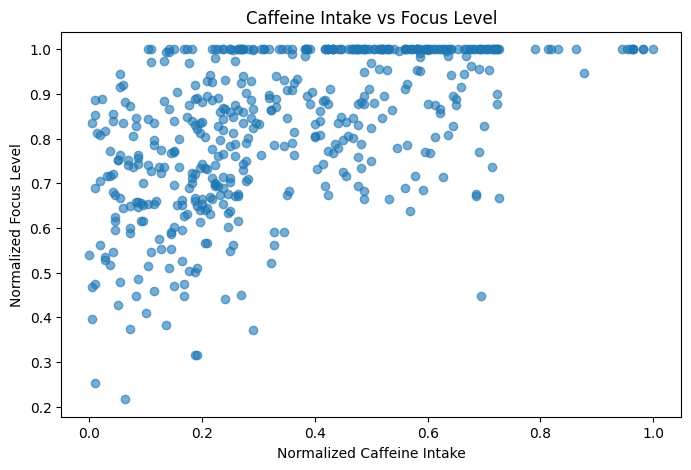

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(data["caffeine_mg"], data["focus_level"], alpha=0.6)

plt.title("Caffeine Intake vs Focus Level")
plt.xlabel("Normalized Caffeine Intake")
plt.ylabel("Normalized Focus Level")

plt.show()

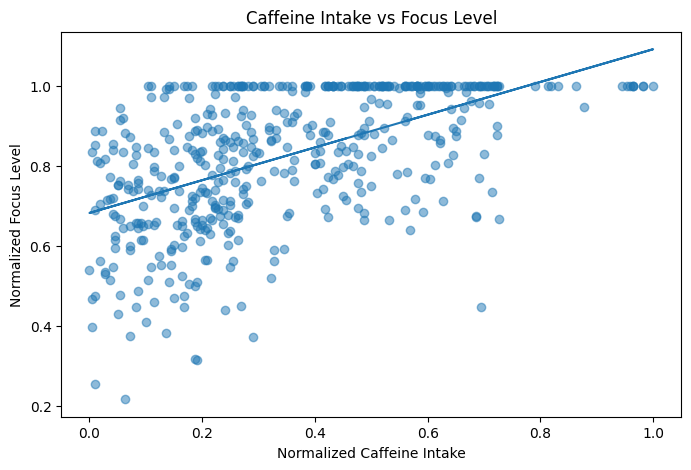

In [34]:
import numpy as np
import matplotlib.pyplot as plt

x = data["caffeine_mg"]
y = data["focus_level"]

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.5)

# Trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.title("Caffeine Intake vs Focus Level")
plt.xlabel("Normalized Caffeine Intake")
plt.ylabel("Normalized Focus Level")

plt.show()

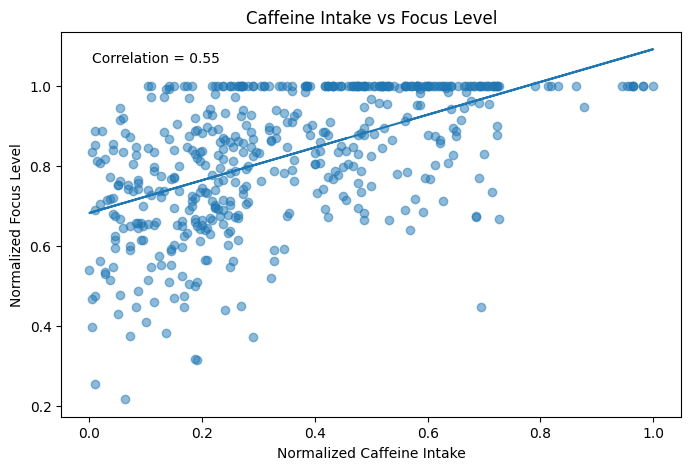

In [35]:
import numpy as np
import matplotlib.pyplot as plt

x = data["caffeine_mg"]
y = data["focus_level"]

correlation = x.corr(y)

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.5)
plt.plot(x, m*x + b)

plt.title("Caffeine Intake vs Focus Level")
plt.xlabel("Normalized Caffeine Intake")
plt.ylabel("Normalized Focus Level")

plt.text(
    0.05, 0.95,
    f"Correlation = {correlation:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.show()

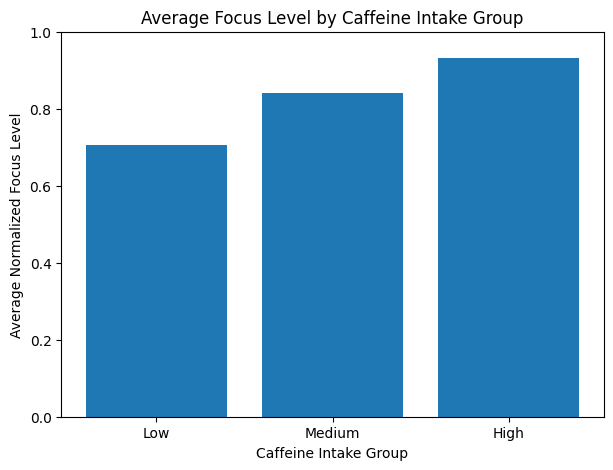

In [36]:
import matplotlib.pyplot as plt

focus_by_caffeine = data.groupby(
    "caffeine_group",
    observed=True
)["focus_level"].mean()

plt.figure(figsize=(7, 5))

plt.bar(
    focus_by_caffeine.index,
    focus_by_caffeine.values
)

plt.title("Average Focus Level by Caffeine Intake Group")
plt.xlabel("Caffeine Intake Group")
plt.ylabel("Average Normalized Focus Level")

plt.ylim(0, 1)

plt.show()

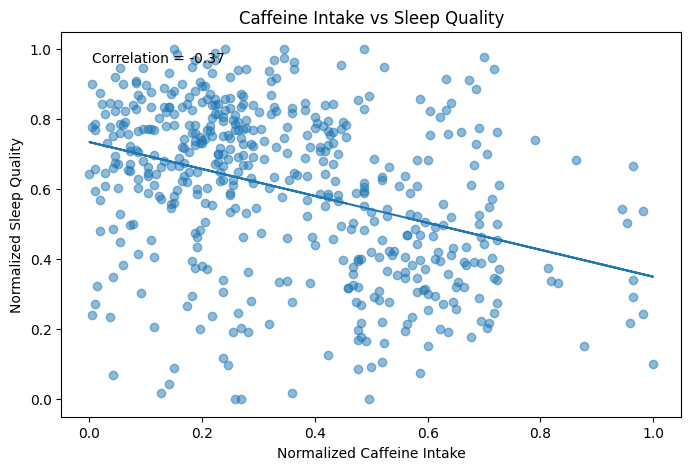

In [37]:
import numpy as np
import matplotlib.pyplot as plt

x = data["caffeine_mg"]
y = data["sleep_quality"]

correlation = x.corr(y)

m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(8, 5))

plt.scatter(x, y, alpha=0.5)
plt.plot(x, m*x + b)

plt.title("Caffeine Intake vs Sleep Quality")
plt.xlabel("Normalized Caffeine Intake")
plt.ylabel("Normalized Sleep Quality")

plt.text(
    0.05, 0.95,
    f"Correlation = {correlation:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.show()

In [38]:
print("=== Caffeine & Focus Analysis ===")

print(f"Caffeine-Focus correlation: {data['caffeine_mg'].corr(data['focus_level']):.2f}")
print(f"Caffeine-Sleep correlation: {data['caffeine_mg'].corr(data['sleep_quality']):.2f}")
print(f"Age-Focus correlation: {data['age'].corr(data['focus_level']):.2f}")

print("\nAverage focus by caffeine group:")
print(data.groupby("caffeine_group", observed=True)["focus_level"].mean())

=== Caffeine & Focus Analysis ===
Caffeine-Focus correlation: 0.55
Caffeine-Sleep correlation: -0.37
Age-Focus correlation: -0.05

Average focus by caffeine group:
caffeine_group
Low       0.704672
Medium    0.841475
High      0.931209
Name: focus_level, dtype: float64


In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'coffee_data', 'sample_data']


In [41]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "archive.zip":
            print(os.path.join(root, file))

/content/drive/MyDrive/Coffee Productivity Analysis/archive.zip


In [42]:
import os

project_folder = "/content/drive/MyDrive/Coffee Productivity Analysis"

print(os.listdir(project_folder))

['archive.zip', 'caffeine_intake_tracker.csv']


In [43]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Coffee Productivity Analysis/archive.zip"
extract_path = "/content/coffee_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['caffeine_intake_tracker.csv']


In [44]:
import shutil

source = "/content/coffee_data/caffeine_intake_tracker.csv"
destination = "/content/drive/MyDrive/Coffee Productivity Analysis/caffeine_intake_tracker.csv"

shutil.copy(source, destination)

print("Dataset saved to Google Drive!")

Dataset saved to Google Drive!
